# **Mestrado em Ciência de Dados - 2.º Ano**
**Aluno:** Miguel Loureiro | 2220134

**Instituição:** Universidade de Leiria e Oeste  

***Dissertação:*** Data Mining Aplicado à Transformação Digital de uma PME Portuguesa de E-commerce: Um Caso de Estudo Integrado

---

# **Notebook 3. Modelação | Baseline de Classificação**
*O presente notebook engloba a primeira etapa da fase de Modelação da metodologia CRISP-DM, na qual é apresentado um problema de classificação supervisionada aplicada à previsão de recompra de clientes.*

---

## **Contextualização do problema em estudo**

### **Problema de negócio**

Identificar antecipadamente os clientes com previsão de recompra, ou seja, clientes que se prevê que voltem a comprar nos próximos 90 dias, de forma a acionar campanhas de retenção personalizadas. Estando a PME inserida num contexto de limitação de recursos de marketing, o maior erro a incorrer assenta em não identificar um cliente que compraria novamente (Falso Negativo), perdendo-se a oportunidade para agir e para envolver o cliente. Por outro lado, identificar um Falso Positivo pressupõe apenas um custo residual associado a uma comunicação adicional que, muito provavelmente, não levaria o cliente a comprar novamente.

### **Formulação do problema de classificação**

**Tarefa:** Classificação binária supervisionada, que consiste em prever se um cliente ativo voltará a comprar nos próximos 90 dias.

**Dimensão:** Clientes com pelo menos 1 compra na janela de features (últimos 180 dias antes do período de target).

**Variável alvo:** `Target_Compra` ∈ {0, 1}.

**Features:** 12 variáveis comportamentais e transacionais derivadas de feature engineering resultante da fase de preparação de dados: RFM (`Recency_FW`, `Monetary_FW`), ticket médio, diversidade de produtos/categorias/marcas/tipos, tempo como cliente, frequência mensal, percentagem de desconto e dias entre compras.

**Métrica principal:** Recall, alinhando-se com o objetivo de minimização de Falsos Negativos.

**Métricas complementares:** F1-Score (equilíbrio entre Recall e Precision) e ROC-AUC (capacidade discriminativa global).

**Distribuição de classes:** ~37% positivos (compraram) / ~63% negativos (não compraram). O desbalanceamento registado será tratado através da aplicação de `class_weight='balanced'`.

### **Seleção de 4 algoritmos**

Para a problemática de classificação a desenvolver são selecionados quatro algoritmos de acordo com a sua complementaridade:

| Algoritmo | Tipo | Justificação |
|-----------|------|--------------|
| **Regressão Logística** | Linear | Baseline interpretável com coeficientes diretamente analisáveis |
| **SVM** | Kernel (não-linear) | Robusto em problemas com fronteiras complexas |
| **Decision Tree** | Não-paramétrico (árvore única) | Interpretabilidade visual e captura interações |
| **Random Forest** | Ensemble (conjunto de árvores) | Robusto a outliers e multicolinearidade |

### **Caracterização do notebook**

Neste notebook é desenvolvida a baseline da modelação através da utilização de hiperparâmetros padrão. Os resultados obtidos criam uma base de referência sobre a qual o próximo notebook (NB4), utilizando otimização por Grid Search, permitirá obter ganhos através de otimização de hiperparâmetros.

### **Boas práticas adotadas**

- **Pipeline (`StandardScaler` + estimador)** - o scaler é ajustado apenas sobre o treino em cada fold, eliminando data leakage que aconteceria ao utilizar normalização global antes da divisão em conjunto de treino e de teste.
- **`cross_val_score` apenas sobre `X_train`** - o conjunto de teste mantém-se inutilizado até à avaliação final independente.
- **`StratifiedKFold` (10 folds, `shuffle=True`, `random_state=42`)** - mantém a proporção de classes em cada fold, garantindo reprodutibilidade.
- **`class_weight='balanced'`** - essencial para fazer face ao desequilíbrio de classes no momento do treino.

---

## **Estrutura do notebook**

1. Importação de bibliotecas
2. Carregamento e validação de dados
3. Modelos baseline
   - 3.1. Definição do dataset (features e target).
   - 3.2. Definição dos modelos (Pipelines).
   - 3.3. Divisão em conjunto de treino e teste (80/20 estratificado).
   - 3.4. Configuração da validação cruzada estratificada (10-fold).
   - 3.5. Avaliação do desempenho via cross-validation.
   - 3.6. Visualização comparativa das métricas.
   - 3.7. Matrizes de confusão sobre o conjunto de teste.
   - 3.8. Tabela comparativa final.
4. Síntese da baseline

## **1. Importação de bibliotecas**

O primeiro passo assenta na importação das bibliotecas essenciais para os processos de manipulação, análise e visualização de dados, sendo selecionadas as seguintes bibliotecas:
- pandas → estruturação e transformação de dados tabulares
- numpy → operações numéricas
- matplotlib / seaborn → visualização

In [1]:
#Importação das bibliotecas essenciais
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## **2. Carregamento e validação de dados**

Após importação das bibliotecas, procede-se à ligação à Google Drive de forma a aceder ao conjunto de dados `dataset_modelo_compra.csv` resultante da fase de preparação de dados.

In [2]:
# Montar a Google Drive para acesso aos ficheiros essenciais
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Carregamento do dataset preparado
df_modelo = pd.read_csv("/content/drive/MyDrive/dataset_modelo_compra.csv")

## **3. Modelos Baseline**

Esta secção retrata o desenvolvimento da baseline de classificação com os quatro algoritmos selecionados (Regressão Logística, SVM, Decision Tree e Random Forest), utilizando o conjunto completo de features obtido na fase anterior de Preparação dos Dados.

Os resultados obtidos nesta secção garantem uma referência para realizar uma análise comparativa em relação aos ganhos que serão obtidos na fase de otimização via Grid Search no próximo notebook.

Este processo implica a importação de:

- **Elementos relevantes para a modelação e avaliação** - `cross_val_score`, `StratifiedKFold` e `train_test_split` para divisão treino/teste e validação cruzada estratificada, assegurando a proporção das classes em cada fold.
- **Pipeline e pré-processamento** - `Pipeline` e `StandardScaler`. A `Pipeline` garante que o `StandardScaler` é aplicado apenas no conjunto de treino em cada fold.
- **Algoritmos de classificação** - Regressão Logística, SVM, Decision Tree e Random Forest.
- **Métricas de avaliação** - `recall`, `f1_score`, `roc_auc_score` e `confusion_matrix`, enfatizando o Recall de acordo com o objetivo de minimização de Falsos Negativos.

In [5]:
# Utilitários de modelação e avaliação
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split

# Pipeline e pré-processamento
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Algoritmos de classificação
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Métricas de avaliação
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay
)

### **3.1. Definição do Dataset**

Segue-se a definição do conjunto de features e da variável alvo a utilizar em todo o processo de modelação associado ao problema de classificação em estudo.

O conjunto de variáveis a utilizar é composto por 12 variáveis comportamentais e transacionais, complementadas pela variável alvo `Target_Compra`, sendo a variável binária que classifica cada cliente como:
- **1** - voltou a comprar na janela de target (próximos 90 dias)
- **0** - não voltou a comprar na janela de target

Os clientes incluídos neste processo consistem em clientes com pelo menos uma compra na janela de features (últimos 180 dias), estando distribuídos da seguinte forma: **37% positivos** (compraram) e **63% negativos** (não compraram).

In [6]:
# Definição de features e target
features = [
    'Recency_FW',
    'Monetary_FW',
    'Ticket_Medio_FW',
    'Produtos_Medios_FW',
    'Freq_Mensal_FW',
    'Dias_Entre_Compras_FW',
    'Tempo_Cliente_FW',
    'Perc_Desconto_FW',
    'Num_Produtos_FW',
    'Num_Categorias_FW',
    'Num_Marcas_FW',
    'Num_Tipos_FW'
]

X = df_modelo[features]
y = df_modelo['Target_Compra']

### **3.2. Definição dos Modelos**

Segue-se a definição dos quatro algoritmos de classificação a utilizar, tendo a sua seleção sido definida com base na complementaridade e adequação ao problema de classificação em questão.

Cada um dos quatro algoritmos é integrado numa **`Pipeline`** que inclui:
1. `StandardScaler` - normaliza as features (média 0, desvio-padrão 1)
2. Estimador (modelo de classificação)

Todos os algoritmos utilizados utilizam dois parâmetros comuns:

- **`class_weight='balanced'`** - atribui automaticamente maior peso à classe minoritária durante o treino, como forma de equilibrar as classes. Esta escolha prende-se com a necessidade de evitar que os modelos privilegiem a classificação da classe maioritária (clientes que não voltam a comprar).

- **`random_state=42`** - garante a reprodutibilidade dos resultados em todas as execuções.

Adicionalmente, são utilizados parâmetros específicos por modelo:

- **Regressão Logística** - `max_iter=1000` garante a convergência do algoritmo de forma a fazer face à complexidade e ao volume dos dados.
- **SVM** - `probability=True` permite o cálculo da métrica ROC-AUC, que requer probabilidades de classificação em vez de apenas classes binárias.

In [7]:
# Dicionário de Pipelines (StandardScaler + estimador)
modelos = {
    "Regressao Logistica": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=1000,
            class_weight='balanced',
            random_state=42
        ))
    ]),
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(
            class_weight='balanced',
            probability=True,
            random_state=42
        ))
    ]),
    "Decision Tree": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", DecisionTreeClassifier(
            class_weight='balanced',
            random_state=42
        ))
    ]),
    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(
            class_weight='balanced',
            random_state=42
        ))
    ])
}

### **3.3. Divisão em conjunto de treino e teste**

De seguida, procede-se à divisão do conjunto de dados em dois subconjuntos distintos: treino (80%) e teste (20%). A divisão é realizada recorrendo ao parâmetro `stratify=y`, mantendo a proporção original de classes em ambos os conjuntos (~37%/63%). Desta forma, é assegurada a validade comparativa dos resultados.

A divisão executada complementa a validação cruzada que será realizada posteriormente, permitindo simular o comportamento dos modelos de acordo com dados futuros não observados durante o treino.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # garante proporção das classes no treino e teste
)

print(f"Dimensão do conjunto de treino: {X_train.shape[0]} registos")
print(f"Dimensão do conjunto de teste: {X_test.shape[0]} registos")
print(f"\nDistribuição da variável alvo no treino:")
print(y_train.value_counts(normalize=True).round(4))
print(f"\nDistribuição da variável alvo no teste:")
print(y_test.value_counts(normalize=True).round(4))

Dimensão do conjunto de treino: 1805 registos
Dimensão do conjunto de teste: 452 registos

Distribuição da variável alvo no treino:
Target_Compra
0    0.6338
1    0.3662
Name: proportion, dtype: float64

Distribuição da variável alvo no teste:
Target_Compra
0    0.635
1    0.365
Name: proportion, dtype: float64


A divisão realizada resulta na seguinte composição de ambos os conjuntos:
- Treino: 1.805 registos
- Teste: 452 registos

A distribuição dos conjuntos mantém-se similar ao pretendido: classe 0 (63%) e classe 1 (36%).

### **3.4. Configuração da validação cruzada estratificada**

Segue-se a aplicação de validação cruzada para a avaliação dos modelos. Os requisitos de aplicação incluem `StratifiedKFold` com 10 folds, estando associado aos seguintes aspetos:

- **Estratificação** - o `StratifiedKFold` garante a proporção de classes (~37%/63%) em cada fold, permitindo que a classe minoritária fique representada em todas as iterações.

- **10 folds** - escolha adequada ao volume de dados disponível (2.257 registos). Neste caso, com 1.805 clientes no conjunto de treino, cada fold de validação é composto por cerca de 180 clientes, tratando-se de um número adequado para uma avaliação robusta.

O parâmetro `shuffle=True` permite uma disposição aleatória dos dados antes da divisão em folds, minimizando a possibilidade de enviesamento por ordenação de registos. O `random_state=42` assegura a reprodutibilidade.

In [9]:
# Validação cruzada estratificada 10-fold
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

### **3.5. Avaliação do desempenho via cross-validation (Conjunto de Treino)**

De seguida, procede-se à avaliação do desempenho dos quatro modelos através da validação cruzada estratificada 10-fold definida anteriormente. A validação cruzada é realizada apenas no conjunto de treino.

Para tal, são utilizadas três métricas:

- **Recall** - mede a capacidade de identificar corretamente os clientes que vão recomprar, tratando-se da principal métrica em caso de minimização dos Falsos Negativos, ou seja, minimizar o número de clientes que se prevê a recompra e que ficariam por identificar e, consequentemente, não seriam desenvolvidas campanhas de retenção.

- **F1-Score** - métrica de equilíbrio harmónico entre Precision e Recall, garantindo que o modelo não maximiza o Recall à custa de uma Precision baixa, isto é, evita classificar demasiados clientes como recompradores gerando um número elevado de Falsos Positivos.

- **ROC-AUC** - avalia a capacidade discriminativa global do modelo, permitindo comparar modelos com dados desbalanceados.

In [10]:
resultados = []

for nome, modelo in modelos.items():

    # Validação cruzada apenas sobre o conjunto de treino
    # A Pipeline garante que o StandardScaler é fit apenas em cada fold de treino
    recall_scores = cross_val_score(modelo, X_train, y_train, scoring='recall',  cv=cv)
    f1_scores     = cross_val_score(modelo, X_train, y_train, scoring='f1',      cv=cv)
    roc_scores    = cross_val_score(modelo, X_train, y_train, scoring='roc_auc', cv=cv)

    resultados.append({
        'Modelo': nome,
        'Recall Medio':    recall_scores.mean(),
        'F1-Score Medio':  f1_scores.mean(),
        'ROC-AUC Medio':   roc_scores.mean(),
    })

# Apresentar resultados ordenados por Recall
df_resultados = pd.DataFrame(resultados).sort_values(
    by='Recall Medio', ascending=False
).round(4)

print("\nResultados Baseline (CV estratificada 10-fold sobre X_train):\n")
print(df_resultados.to_string(index=False))


Resultados Baseline (CV estratificada 10-fold sobre X_train):

             Modelo  Recall Medio  F1-Score Medio  ROC-AUC Medio
                SVM        0.7488          0.7133         0.8369
Regressao Logistica        0.7352          0.7137         0.8581
      Random Forest        0.6506          0.6909         0.8619
      Decision Tree        0.6158          0.6125         0.6946


In [11]:
# Exportação dos resultados da validação cruzada
df_resultados.to_csv(
    "/content/drive/MyDrive/resultados_classificacao_baseline_cv.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Resultados baseline CV exportados: resultados_classificacao_baseline_cv.csv")

Resultados baseline CV exportados: resultados_classificacao_baseline_cv.csv


Os resultados obtidos através de validação cruzada estratificada (10-fold) traduzem um desempenho satisfatório dos modelos avaliados, sendo de destacar o **SVM** e a **Regressão Logística**, que obtiveram melhores resultados ao nível do Recall (métrica primária):

- A **SVM** apresentou o melhor valor de **Recall médio (0,7488)**, traduzindo que aproximadamente 75% dos clientes que voltam a comprar são corretamente identificados pelo modelo. O resultado verificado na **Regressão Logística** foi ligeiramente inferior ao nível do Recall (0,7352), no entanto verificou-se que apresentou melhor equilíbrio global entre as métricas avaliadas através de um maior **F1-Score (0,7137)** e um elevado **ROC-AUC (0,8581)**.

- O **Random Forest** evidenciou a mais elevada capacidade discriminativa (**ROC-AUC = 0,8619**), mas obteve um Recall significativamente inferior (0,6506), reforçando uma menor eficácia na identificação de clientes com maior probabilidade de recompra. O outro modelo tree-based, a **Decision Tree**, apresentou um desempenho inferior aos restantes em todas as três métricas analisadas, revelando uma menor capacidade preditiva.

Resumidamente, os resultados constatam que os modelos lineares (Regressão Logística) e baseados em margens de separação (SVM) são os mais adequados para o problema de previsão de recompra em estudo em contexto de baseline, levando à necessidade de posterior otimização através de Grid Search para averiguar os ganhos por otimização de hiperparâmetros.

### **3.6. Visualização comparativa das métricas em validação cruzada**

De forma a facilitar a visualização comparativa das métricas nos diferentes modelos, é realizada uma representação gráfica com recurso a um gráfico de barras agrupadas.

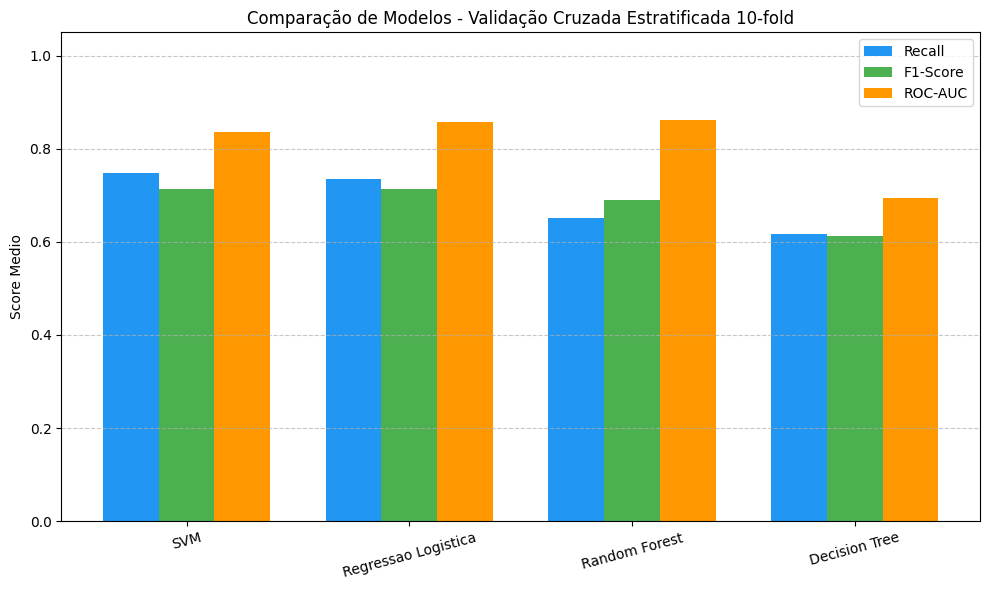

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(df_resultados['Modelo']))
largura = 0.25

ax.bar(x - largura, df_resultados['Recall Medio'], largura, label='Recall', color='#2196F3')
ax.bar(x, df_resultados['F1-Score Medio'], largura, label='F1-Score', color='#4CAF50')
ax.bar(x + largura, df_resultados['ROC-AUC Medio'], largura, label='ROC-AUC', color='#FF9800')

ax.set_title('Comparação de Modelos - Validação Cruzada Estratificada 10-fold')
ax.set_ylabel('Score Medio')
ax.set_xticks(x)
ax.set_xticklabels(df_resultados['Modelo'], rotation=15)
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### **3.7. Matrizes de confusão sobre o conjunto de teste**

O recurso à matriz de confusão permite avaliar detalhadamente o desempenho de cada modelo no conjunto de teste, de acordo com quatro componentes essenciais:

- **Verdadeiros Positivos (VP)** - clientes que realizaram uma nova compra na janela de target, tendo sido classificados corretamente pelo modelo.
- **Verdadeiros Negativos (VN)** - clientes que não efetuaram qualquer compra na janela de target e que foram corretamente classificados pelo modelo como não compradores.
- **Falsos Positivos (FP)** - clientes classificados pelo modelo como compradores, mas que não realizaram qualquer compra na janela de target. Esta ocorrência pode levar a que se realizem campanhas promocionais ou ações de marketing desnecessárias.
- **Falsos Negativos (FN)** - clientes que efetivamente realizaram uma compra na janela de target, mas que não foram identificados pelo modelo. Esta situação resulta na perda de oportunidades de estimular ou antecipar a recompra.

Modelo treinado e guardado: regressao_logistica_pipeline.pkl


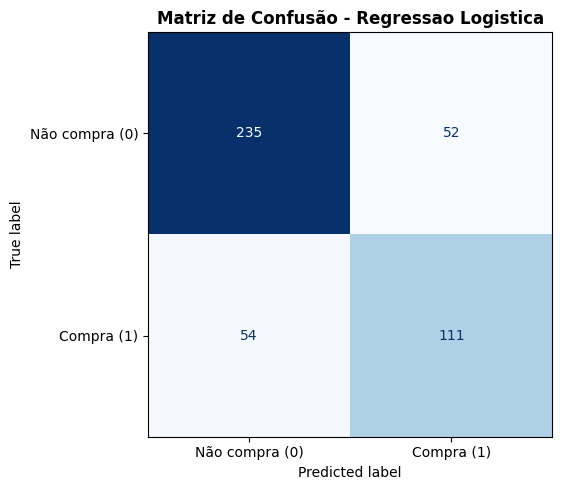


Modelo: Regressao Logistica
Verdadeiros Negativos (VN): 235 - clientes que não compram, corretamente identificados
Falsos Positivos      (FP): 52 - clientes que não compram, classificados como compradores
Falsos Negativos      (FN): 54 - clientes que compram, não identificados pelo modelo
Verdadeiros Positivos (VP): 111 - clientes que compram, corretamente identificados

Taxa de Falsos Negativos: 32.73%
Taxa de Falsos Positivos: 18.12%

                precision    recall  f1-score   support

Não compra (0)       0.81      0.82      0.82       287
    Compra (1)       0.68      0.67      0.68       165

      accuracy                           0.77       452
     macro avg       0.75      0.75      0.75       452
  weighted avg       0.76      0.77      0.77       452

Modelo treinado e guardado: svm_pipeline.pkl


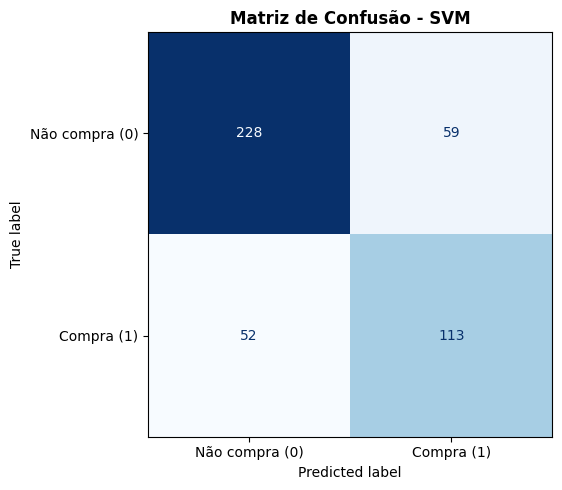


Modelo: SVM
Verdadeiros Negativos (VN): 228 - clientes que não compram, corretamente identificados
Falsos Positivos      (FP): 59 - clientes que não compram, classificados como compradores
Falsos Negativos      (FN): 52 - clientes que compram, não identificados pelo modelo
Verdadeiros Positivos (VP): 113 - clientes que compram, corretamente identificados

Taxa de Falsos Negativos: 31.52%
Taxa de Falsos Positivos: 20.56%

                precision    recall  f1-score   support

Não compra (0)       0.81      0.79      0.80       287
    Compra (1)       0.66      0.68      0.67       165

      accuracy                           0.75       452
     macro avg       0.74      0.74      0.74       452
  weighted avg       0.76      0.75      0.76       452

Modelo treinado e guardado: decision_tree_pipeline.pkl


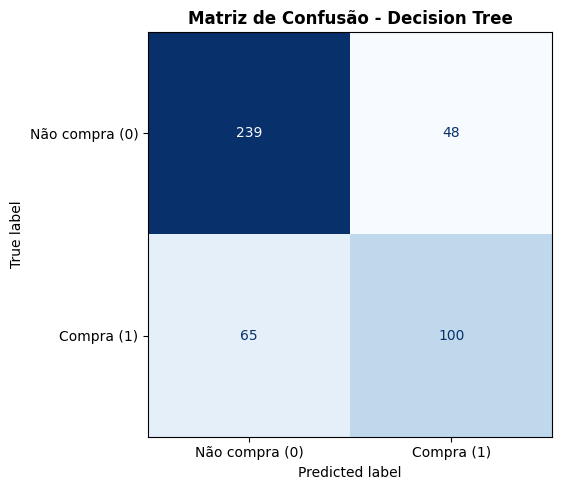


Modelo: Decision Tree
Verdadeiros Negativos (VN): 239 - clientes que não compram, corretamente identificados
Falsos Positivos      (FP): 48 - clientes que não compram, classificados como compradores
Falsos Negativos      (FN): 65 - clientes que compram, não identificados pelo modelo
Verdadeiros Positivos (VP): 100 - clientes que compram, corretamente identificados

Taxa de Falsos Negativos: 39.39%
Taxa de Falsos Positivos: 16.72%

                precision    recall  f1-score   support

Não compra (0)       0.79      0.83      0.81       287
    Compra (1)       0.68      0.61      0.64       165

      accuracy                           0.75       452
     macro avg       0.73      0.72      0.72       452
  weighted avg       0.75      0.75      0.75       452

Modelo treinado e guardado: random_forest_pipeline.pkl


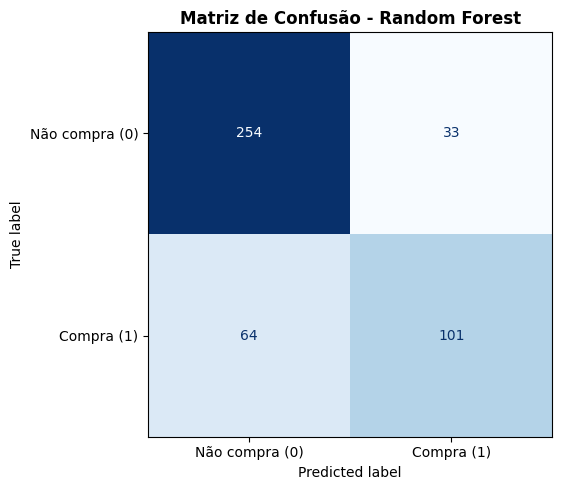


Modelo: Random Forest
Verdadeiros Negativos (VN): 254 - clientes que não compram, corretamente identificados
Falsos Positivos      (FP): 33 - clientes que não compram, classificados como compradores
Falsos Negativos      (FN): 64 - clientes que compram, não identificados pelo modelo
Verdadeiros Positivos (VP): 101 - clientes que compram, corretamente identificados

Taxa de Falsos Negativos: 38.79%
Taxa de Falsos Positivos: 11.50%

                precision    recall  f1-score   support

Não compra (0)       0.80      0.89      0.84       287
    Compra (1)       0.75      0.61      0.68       165

      accuracy                           0.79       452
     macro avg       0.78      0.75      0.76       452
  weighted avg       0.78      0.79      0.78       452



In [13]:
import joblib
import os

os.makedirs("/content/drive/MyDrive/modelos", exist_ok=True)

for nome, modelo in modelos.items():
    nome_ficheiro = nome.replace(" ", "_").lower()
    caminho = f"/content/drive/MyDrive/modelos/{nome_ficheiro}_pipeline.pkl"

    if os.path.exists(caminho):
        modelos[nome] = joblib.load(caminho)
        print(f"Modelo carregado: {nome_ficheiro}_pipeline.pkl")
    else:
        modelo.fit(X_train, y_train)
        joblib.dump(modelo, caminho)
        print(f"Modelo treinado e guardado: {nome_ficheiro}_pipeline.pkl")

    y_pred = modelos[nome].predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Não compra (0)', 'Compra (1)']
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Matriz de Confusão - {nome}', fontweight='bold')
    plt.tight_layout()
    plt.show()

    vn, fp, fn, vp = cm.ravel()
    print(f"\n{'='*55}")
    print(f"Modelo: {nome}")
    print(f"{'='*55}")
    print(f"Verdadeiros Negativos (VN): {vn} - clientes que não compram, corretamente identificados")
    print(f"Falsos Positivos      (FP): {fp} - clientes que não compram, classificados como compradores")
    print(f"Falsos Negativos      (FN): {fn} - clientes que compram, não identificados pelo modelo")
    print(f"Verdadeiros Positivos (VP): {vp} - clientes que compram, corretamente identificados")
    print(f"\nTaxa de Falsos Negativos: {fn/(fn+vp):.2%}")
    print(f"Taxa de Falsos Positivos: {fp/(fp+vn):.2%}")
    print(f"\n{classification_report(y_test, y_pred, target_names=['Não compra (0)', 'Compra (1)'])}")

A análise das matrizes de confusão dos quatro modelos permite compreender de forma mais detalhada o desempenho ao nível da identificação de clientes compradores e da redução de classificações incorretas.

- A **Regressão Logística** identificou corretamente 111 dos 165 clientes que realizaram uma nova compra, evidenciando um número semelhante de falsos negativos (54) e de falsos positivos (52). Esta semelhança de valores em ambos os erros (FN e FP) permitem concluir que o modelo é estável e capaz de identificar clientes compradores sem que seja necessário criar um número excessivo de campanhas potencialmente desnecessárias.

- A **SVM** apresentou o menor número de falsos negativos (52) em comparação com os restantes modelos e identificou corretamente 113 clientes compradores. Este resultado constata a sua maior capacidade de deteção de clientes com potencial de recompra. No entanto, este resultado positivo levou a um aumento dos falsos positivos (59), tendo sido o valor mais elevado registado entre os modelos.

- A **Decision Tree** obteve um bom desempenho na redução dos falsos positivos para 48, mas, por outro lado, aumentou os falsos negativos para 65, permitindo concluir que este modelo não permite captar um maior número de clientes que efetivamente voltariam a comprar.

- Por fim, o **Random Forest** obteve a menor taxa de falsos positivos (11,5%), com apenas 33 Falsos Positivos, classificando corretamente 254 clientes que não voltaram a realizar compras. Contudo, o melhor desempenho de FP levou a um elevado número de falsos negativos (64), restringindo a sua capacidade de identificar oportunidades de recompra.

Em conclusão, enquanto a **SVM** privilegia a identificação de clientes compradores através da aceitação de mais falsos alarmes, o **Random Forest** está associado a um comportamento mais conservador, dado que reduz campanhas desnecessárias, mas deixa escapar mais clientes com potencial de recompra. A **SVM** resulta no modelo mais adequado ao objetivo em questão, enquanto a **Decision Tree** apresenta o desempenho menos favorável.

### **3.8. Tabela Comparativa Final (Conjunto de Teste)**

Com o intuito de facilitar a apresentação conjunta dos resultados entre os diversos modelos no conjunto de teste, é apresentada uma tabela comparativa.

In [14]:
# Tabela resumo comparativa
resumo = []

for nome, modelo in modelos.items():
    y_pred = modelo.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    vn, fp, fn, vp = cm.ravel()

    resumo.append({
        'Modelo': nome,
        'Recall': round(recall_score(y_test, y_pred), 4),
        'F1-Score': round(f1_score(y_test, y_pred), 4),
        'ROC-AUC': round(roc_auc_score(y_test, y_pred), 4),
        'Falsos Negativos': fn,
        'Falsos Positivos': fp,
        'Taxa FN': f"{fn/(fn+vp):.2%}",
        'Taxa FP': f"{fp/(fp+vn):.2%}"
    })

df_resumo = pd.DataFrame(resumo).sort_values(by='Recall', ascending=False)

print("\nTabela Comparativa\n")
print(df_resumo.to_string(index=False))


Tabela Comparativa

             Modelo  Recall  F1-Score  ROC-AUC  Falsos Negativos  Falsos Positivos Taxa FN Taxa FP
                SVM  0.6848    0.6706   0.7396                52                59  31.52%  20.56%
Regressao Logistica  0.6727    0.6768   0.7458                54                52  32.73%  18.12%
      Random Forest  0.6121    0.6756   0.7486                64                33  38.79%  11.50%
      Decision Tree  0.6061    0.6390   0.7194                65                48  39.39%  16.72%


In [15]:
# Exportação da tabela comparativa final da baseline
df_resumo.to_csv(
    "/content/drive/MyDrive/resultados_classificacao_baseline_teste.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Resultados baseline no teste exportados: resultados_classificacao_baseline_teste.csv")

Resultados baseline no teste exportados: resultados_classificacao_baseline_teste.csv


## **4. Síntese da baseline**

A construção da baseline de classificação permitiu criar a referência para que a fase de Grid Search a implementar no notebook seguinte possa ser avaliada. Os
resultados sintetizam-se da seguinte forma:

- **Os quatro algoritmos captam sinal preditivo:** Todos os algoritmos apresentam valores de Recall entre 0,60 e 0,69 e de F1-Score entre 0,64 e 0,68 no conjunto de teste, o que constata que as 12 features construídas na preparação de dados contêm informação discriminativa e útil para prever a recompra nos próximos 90 dias.

- **SVM e Regressão Logística com maior Recall no conjunto de teste:** O SVM apresenta o maior Recall (0,6848), seguindo-se a Regressão Logística (0,6727). Estes modelos permitem minimizar os Falsos Negativos com maior eficácia em comparação com os restantes.

- **Decision Tree é o modelo com pior desempenho global:** Com um Recall de 0,6061 e apresentando o maior número de Falsos Negativos (65), será este o algoritmo com maior potencial de otimização na fase seguinte.

- **Nenhum modelo cumpre o critério de Recall ≥ 0,70 do ODM1:** O
melhor resultado de Recall obtido consiste em 0,6848 no SVM, ficando aquém do limite mínimo no objetivo de data mining definido, permitindo concluir que a baseline não é uma solução final. Desta forma, será necessária a otimização de hiperparâmetros via Grid Search na próxima fase, incluindo seleção de variáveis, com o objetivo de melhorar o valor do Recall e assegurar uma generalização robusta no conjunto de teste.